In [1]:
# FORECASTING EXCHANGE RATES USING TIME SERIES ANALYSIS:

In [2]:
# Objective:
# Leverage ARIMA and Exponential Smoothing techniques to forecast future exchange rates based on historical data provided in the exchange_rate.csv dataset.

# Dataset:
# The dataset contains historical exchange rate with each column representing a different currency rate over time. The first column indicates the date, and the second column represents exchange rates USD to Australian Dollar.

In [3]:
# Part 1: Data Preparation and Exploration :

#    1. Data Loading: Load the exchange_rate.csv dataset and parse the date column appropriately.
#    2. Initial Exploration: Plot the time series for currency to understand their trends, seasonality, and any anomalies.
#    3. Data Preprocessing: Handle any missing values or anomalies identified during the exploration phase.

In [4]:
# Load the Dataset 
import pandas as pd 

df1 = pd.read_csv("exchange_rate.csv")

In [5]:
# Head of the Dataset 
df1.head()

,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


In [6]:
# General Information 
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     7588 non-null   object 
 1   Ex_rate  7588 non-null   float64
dtypes: float64(1), object(1)
memory usage: 118.7+ KB


In [7]:
# Parse the Date Columns 
df = pd.read_csv("exchange_rate.csv", parse_dates = True, index_col = "date")

In [8]:
# Head of the Data
df.head()

,Ex_rate
date,
01-01-1990 00:00,0.7855
02-01-1990 00:00,0.7818
03-01-1990 00:00,0.7867
04-01-1990 00:00,0.7860
05-01-1990 00:00,0.7849


In [9]:
# General Information
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7588 entries, 01-01-1990 00:00 to 10-10-2010 00:00
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ex_rate  7588 non-null   float64
dtypes: float64(1)
memory usage: 118.6+ KB


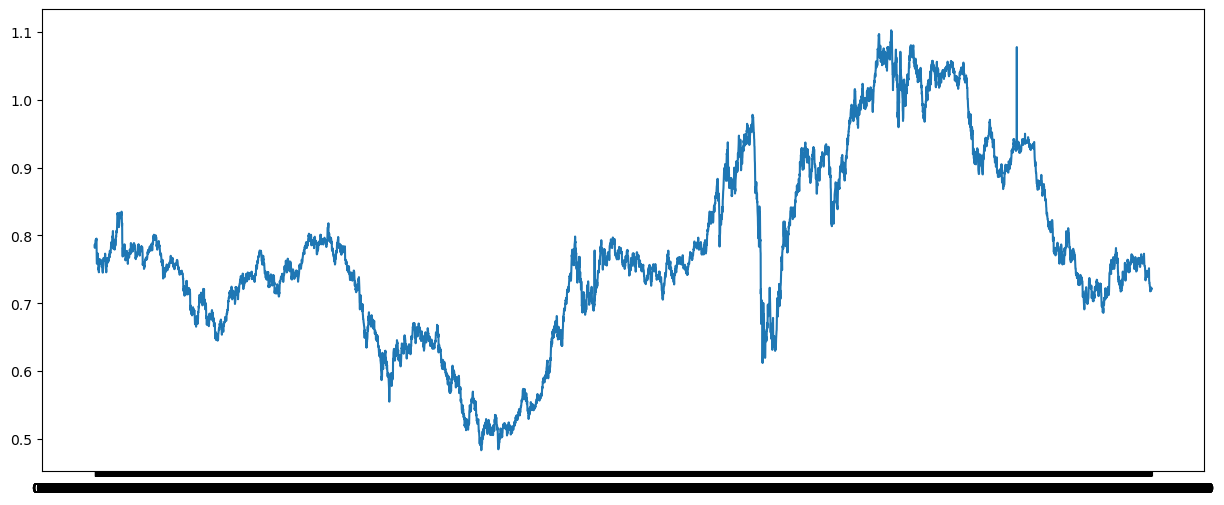

In [10]:
# Plot the Dataset 
import matplotlib.pyplot as plt 

plt.figure(figsize = (15,6))
plt.plot(df)
plt.show()

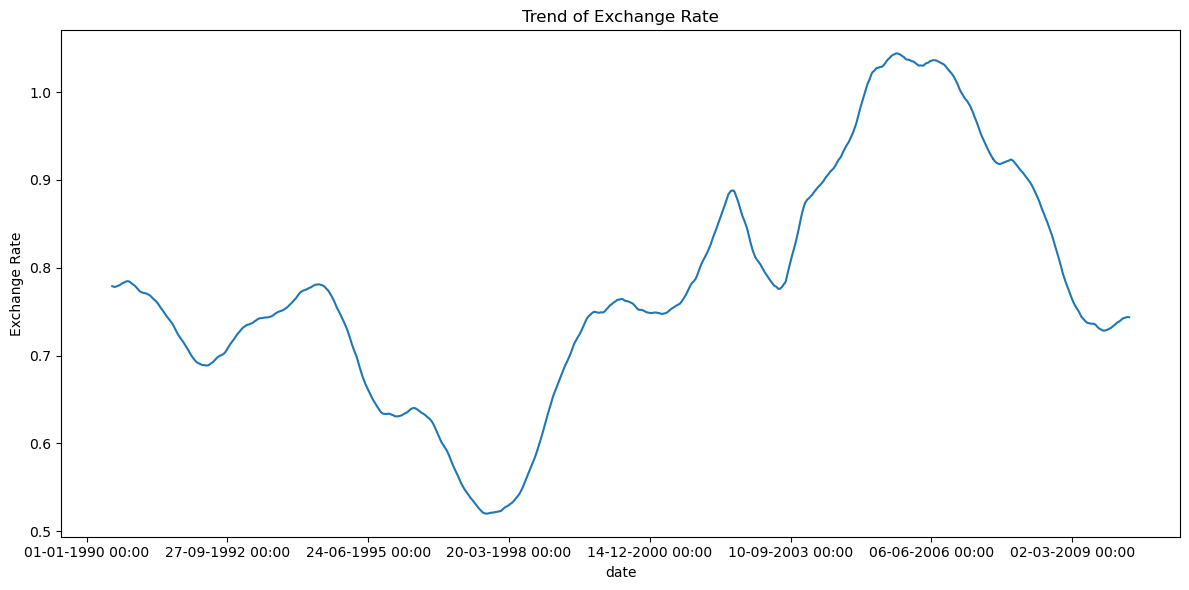

In [11]:
# To Plot Trend of Exchange Rate Pattern  

from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
plt.figure(figsize =(12, 6))
result = seasonal_decompose(df['Ex_rate'], model = 'additive', period = 365)
# To Generete Trend 
plt.title("Trend of Exchange Rate")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
result.trend.plot()
plt.tight_layout ()

<Axes: title={'center': 'Residual Plot'}, xlabel='date', ylabel='Exchange Rate'>

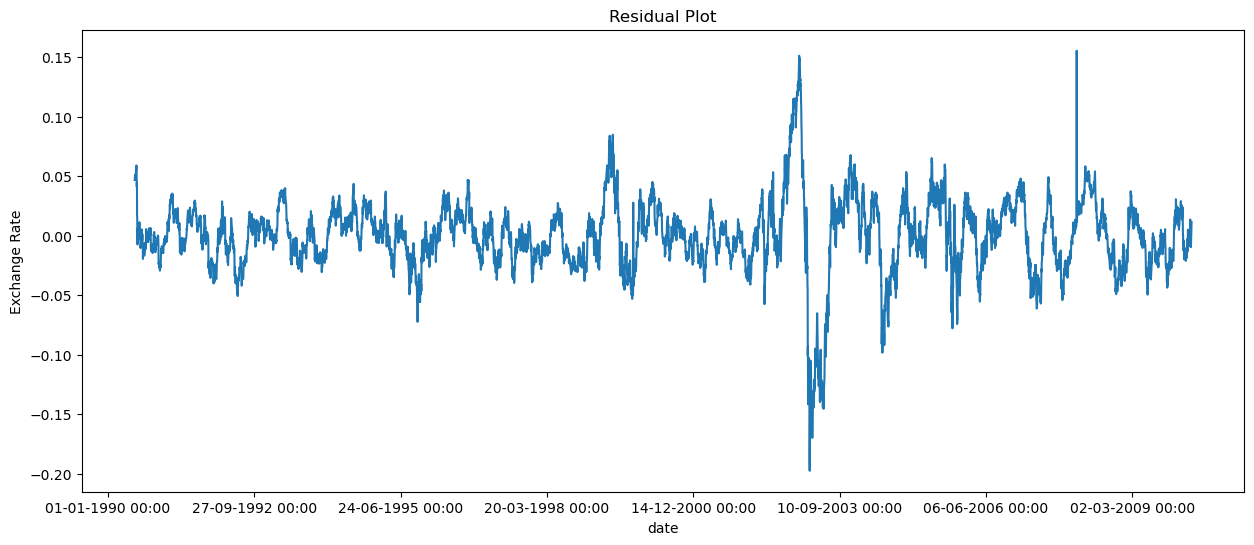

In [12]:
# Residual plot 
import matplotlib.pyplot as plt 

plt.figure(figsize = (15, 6))
plt.title("Residual Plot")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
result.resid.plot()

Text(0, 0.5, 'Exchange Rate')

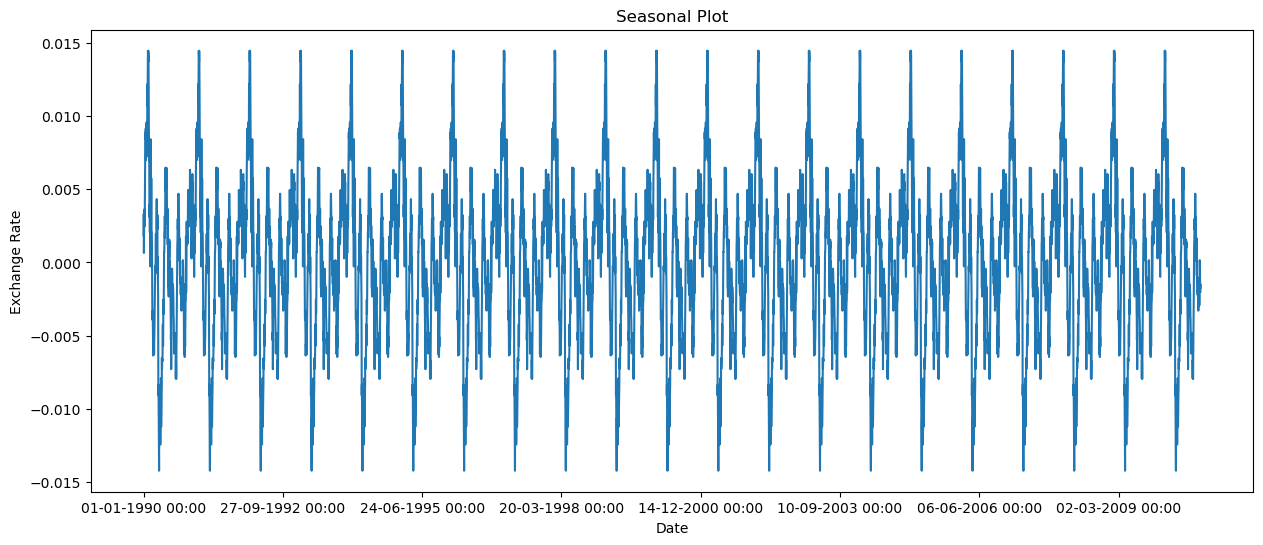

In [13]:
# To Generate Seasonal Plot 
import matplotlib.pyplot as plt 

plt.figure(figsize = (15,6))
result.seasonal.plot()
plt.title("Seasonal Plot")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")

In [14]:
# Check Missing Values
df.isnull().sum()

Ex_rate    0
dtype: int64

In [ ]:
# Part 2: Model Building - ARIMA:

#      1. Parameter Selection for ARIMA: Utilize ACF and PACF plots to estimate initial parameters (p, d, q) for the ARIMA model for one or more currency time series.
#      2. Model Fitting: Fit the ARIMA model with the selected parameters to the preprocessed time series.
#      3. Diagnostics: Analyze the residuals to ensure there are no patterns that might indicate model inadequacies. 
#      4. Forecasting: Perform out-of-sample forecasting and visualize the predicted values against the actual values.

In [15]:
# Load the Dataset
rate = pd.read_csv("exchange_rate.csv", parse_dates = True, index_col= "date")

In [16]:
# Head of the Dataset 
rate.head()

,Ex_rate
date,
01-01-1990 00:00,0.7855
02-01-1990 00:00,0.7818
03-01-1990 00:00,0.7867
04-01-1990 00:00,0.7860
05-01-1990 00:00,0.7849


In [17]:
# To check data is Stationary or not 
import matplotlib.pyplot as plt 
from statsmodels.tsa.stattools import adfuller,acf,pacf
def test_stationarity(timeseries):
    # Calculating rolling mean and rolling standard deviation 
    rolmean = timeseries.rolling(window = 363).mean()
    rolsted = timeseries.rolling(window = 365).std()

    original = plt.plot(timeseries, color = 'blue', label = "Origianl")
    mean = plt.plot(rolmean, color = 'red', label = "Rolling Mean")
    std = plt.plot(rolsted, color = 'green', label = "Rolling Std")
    plt.legend(loc = 'best')

    print("Result of Dickey-Fullar Test:\n")
    df_test = adfuller(timeseries)
    my_output = pd.Series(df_test[0:4], index = ['Test Statistic', 'p_value','#Lags Used','Number of Observations Used'])
    for i, j in df_test[4].items():
        my_output['Critical Value(%)%i'] = j
    print(my_output)

Result of Dickey-Fullar Test:

Test Statistic                   -1.664994
p_value                           0.449233
#Lags Used                        1.000000
Number of Observations Used    7586.000000
Critical Value(%)%i              -2.566973
dtype: float64


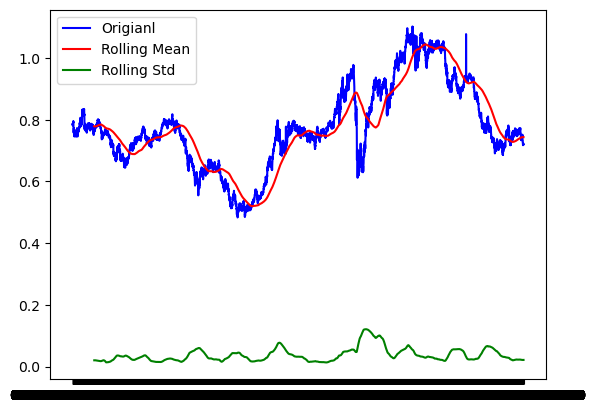

In [18]:
# To check Data is Stationary or not.
test_stationarity(rate['Ex_rate'])

In [19]:
# To make data Stationary 
rate['rate_diff'] = rate['Ex_rate'] - rate['Ex_rate'].shift(365)

In [20]:
# View of the dataset
rate

,Ex_rate,rate_diff
date,,
01-01-1990 00:00,0.785500,NaN
02-01-1990 00:00,0.781800,NaN
03-01-1990 00:00,0.786700,NaN
04-01-1990 00:00,0.786000,NaN
05-01-1990 00:00,0.784900,NaN
...,...,...
06-10-2010 00:00,0.718494,-0.007617
07-10-2010 00:00,0.721839,-0.007396
08-10-2010 00:00,0.723197,-0.005215


In [21]:
# Drop Missing values
rate.dropna(inplace = True)

In [22]:
# Verify
rate

,Ex_rate,rate_diff
date,,
01-01-1991 00:00,0.764500,-0.021000
02-01-1991 00:00,0.765000,-0.016800
03-01-1991 00:00,0.767000,-0.019700
04-01-1991 00:00,0.767500,-0.018500
05-01-1991 00:00,0.767000,-0.017900
...,...,...
06-10-2010 00:00,0.718494,-0.007617
07-10-2010 00:00,0.721839,-0.007396
08-10-2010 00:00,0.723197,-0.005215


Result of Dickey-Fullar Test:

Test Statistic                   -3.501093
p_value                           0.007959
#Lags Used                       29.000000
Number of Observations Used    7193.000000
Critical Value(%)%i              -2.566984
dtype: float64


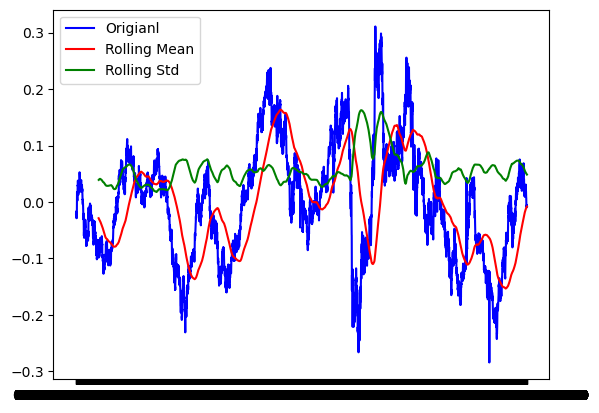

In [23]:
# To check dataset is stationary or not .
test_stationarity(rate['rate_diff'])

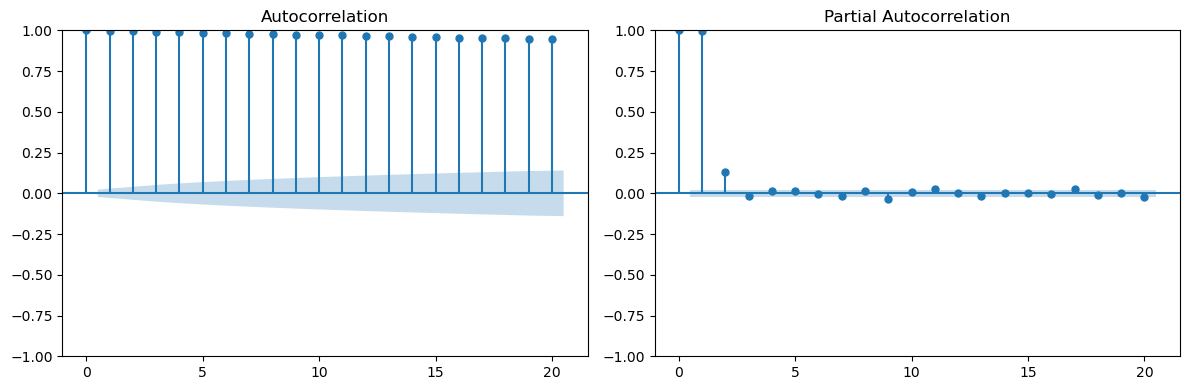

In [24]:
import matplotlib.pyplot as plt
# from statsmodels.tsa.arima.model import ARIMA
import statsmodels.tsa.api as smt

fig, axes = plt.subplots(1,2)
fig.set_figwidth(12)
fig.set_figheight(4)
smt.graphics.plot_acf(rate['rate_diff'], lags = 20, ax = axes[0])
smt.graphics.plot_pacf(rate['rate_diff'], lags = 20, ax = axes[1])
plt.tight_layout()

In [25]:
# P_Value = 1 
# Q_ Value = 1/2/3/4/5

In [26]:
# Model Train 
from statsmodels.tsa.arima.model import ARIMA

import warnings
warnings.filterwarnings('ignore')

model = ARIMA(rate['Ex_rate'], order = (1,1,5)) # P_Value , D_value, Q_value

In [27]:
rate.columns

Index(['Ex_rate', 'rate_diff'], dtype='object')

In [28]:
rate.head()

,Ex_rate,rate_diff
date,,
01-01-1991 00:00,0.7645,-0.0210
02-01-1991 00:00,0.7650,-0.0168
03-01-1991 00:00,0.7670,-0.0197
04-01-1991 00:00,0.7675,-0.0185
05-01-1991 00:00,0.7670,-0.0179


In [29]:
# Model Training 
result = model.fit()

# Modle Prediction 
result.predict()

date
01-01-1991 00:00    0.000000
02-01-1991 00:00    0.764500
03-01-1991 00:00    0.764932
04-01-1991 00:00    0.766727
05-01-1991 00:00    0.767413
                      ...   
06-10-2010 00:00    0.718795
07-10-2010 00:00    0.718547
08-10-2010 00:00    0.721390
09-10-2010 00:00    0.723016
10-10-2010 00:00    0.721059
Name: predicted_mean, Length: 7223, dtype: float64

In [30]:
# Add new columns in the Dataset 
rate['Predict'] = result.predict()

In [31]:
rate.head()

,Ex_rate,rate_diff,Predict
date,,,
01-01-1991 00:00,0.7645,-0.0210,0.000000
02-01-1991 00:00,0.7650,-0.0168,0.764500
03-01-1991 00:00,0.7670,-0.0197,0.764932
04-01-1991 00:00,0.7675,-0.0185,0.766727
05-01-1991 00:00,0.7670,-0.0179,0.767413


In [32]:
# Forecast for next 365 days
forecast = result.forecast(365)

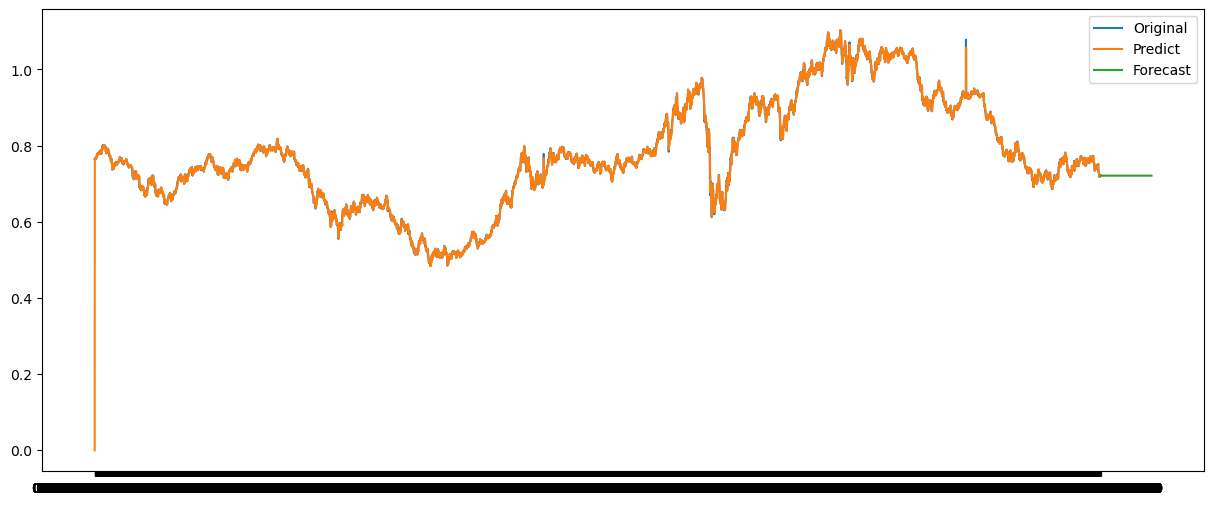

In [33]:
# Visualization 
import matplotlib.pyplot as plt 
plt.figure(figsize = (15,6))
plt.plot(rate['Ex_rate'], label = "Original")
plt.plot(rate['Predict'], label = "Predict")
plt.plot(forecast, label = "Forecast")
plt.legend()
plt.show()

In [ ]:
# Part 3: Evaluation and Comparison:

# 1. Compute Error Metrics: Use metrics such as MAE, RMSE, and MAPE to evaluate the forecasts from both models.

In [34]:
# Compute Error Metrics: Use metrics such as MAE, RMSE, and MAPE to evaluate the forecasts from both models. 
from sklearn.metrics import (mean_absolute_percentage_error,
                            mean_squared_error,
                            mean_absolute_error)
mae = mean_absolute_error(rate['Ex_rate'], rate['Predict'])
mse = mean_squared_error(rate['Ex_rate'], rate['Predict'])
mape = mean_absolute_percentage_error(rate['Ex_rate'], rate['Predict']) *100


print("Mean Absolute Error:",mae)
print("Mean Squared Error:",mse)
print("Mean Absolute Percentage Error:",mape)

Mean Absolute Error: 0.0038274464814251658
Mean Squared Error: 0.00011763842553819487
Mean Absolute Percentage Error: 0.4998931179988615


In [ ]:
# 2. Model Comparison: Discuss the performance, advantages, and limitations of each model based on the observed results and error metrics.

# Interpretation: The forecasting model demonstrates good predictive performance based on the obtained error metrics. The MAE of 0.00383 indicates that the average absolute difference between the actual and predicted exchange rates is relatively small. The MSE of 0.000118 also indicates low prediction error, while the MAPE of approximately 0.50% suggests that the forecasts deviate from the actual exchange rates by only about half a percent on average.

# Advantages and limitations

# Advantages:

# MAE is easy to interpret in the original exchange-rate units.
# RMSE gives more importance to larger forecasting errors.
# MAPE provides an intuitive percentage-based measure.
# Your MAPE of ~0.50% indicates relatively accurate forecasts.

# Limitations:

# Error metrics alone don't tell you whether the model captures trends or sudden changes well.
# MAPE can be problematic when actual values are zero or very close to zero.
# A model with good average metrics can still perform poorly during unusual market movements.
# For time-series forecasting, evaluation should be performed on a chronologically separated test set, not by comparing predictions against the entire dataset if those predictions were generated from data the model was trained on.

In [ ]:
# 3. Conclusion: Summarize the findings and provide insights on which model(s) yielded the best performance for forecasting exchange rates in this dataset.

# Based on the observed error metrics, the forecasting model performs well on the exchange-rate dataset. The MAE of 0.00383, MSE of 0.000118, and MAPE of approximately 0.50% indicate relatively small forecasting errors. When comparing two models, the model with lower MAE, RMSE, and MAPE should generally be preferred. However, model selection should also consider residual diagnostics, computational complexity, interpretability, and performance on unseen future data.

In [ ]:
# Deliverables:

# ● Include visualizations and explanations for the choices and findings at each step.
# ● Well-commented Python code that used to conduct the analysis and build the models.

In [ ]:
# Assessment Criteria:
    
# ● Accuracy and completeness of the data preparation and exploration steps.
# ● Justification for model selection and parameter tuning decisions.
# ● Clarity and depth of the analysis in the diagnostics and model evaluation stages.
# This assignment offers hands-on experience with real-world data, applying sophisticated time series forecasting methods to predict future currency exchange rates.